In [1]:
import sys, os, re, jax
sys.path.append(os.path.abspath("./../../feedback-grape"))
sys.path.append(os.path.abspath("./../../"))
sys.path.append(os.path.abspath("./../"))

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from plot_helpers import (
    open_from_dir,
    plot_runs,
    plot_runs_1D,
    plot_grid,
    grid_grouped_params,
    select_best_runs,
    extract_time_constants,
    sort_by,
    _labels_from_params,
)

In [2]:
dir_ = "./02_results"
#favour_oscillations = lambda fidelities: np.mean([np.max(fidelities[i:i+4]) for i in range(0, len(fidelities), 4)])
fidelities_mat, params_grouped, params_each = open_from_dir(dir_ + "/eval")
fidelities_best_mat, params_grouped_best, params_each_best = select_best_runs(fidelities_mat, params_each)#, objective_fun=favour_oscillations)

fidelities_mat_stab, params_grouped_stab, params_each_stab = open_from_dir(dir_ + "/custom/Stabilizer code")
fidelities_mat_stab, params_grouped_stab, params_each_stab = sort_by(fidelities_mat_stab, params_each_stab, params_each_best, ignored_keys=["s", "l", "rhoe", "Nmeas"], do_remove_missing=True) # to have same order as before. Ignore params not needed for stabilizer code. Also ignore "rhoe" because of earlier bug in saving/loading.

Opening files...


100%|██████████| 576/576 [00:01<00:00, 573.72it/s]


Done.
Opening files...


100%|██████████| 144/144 [00:00<00:00, 1582.47it/s]

Done.


Text(0.5, 1.0, 'Fidelity over Time for all runs')

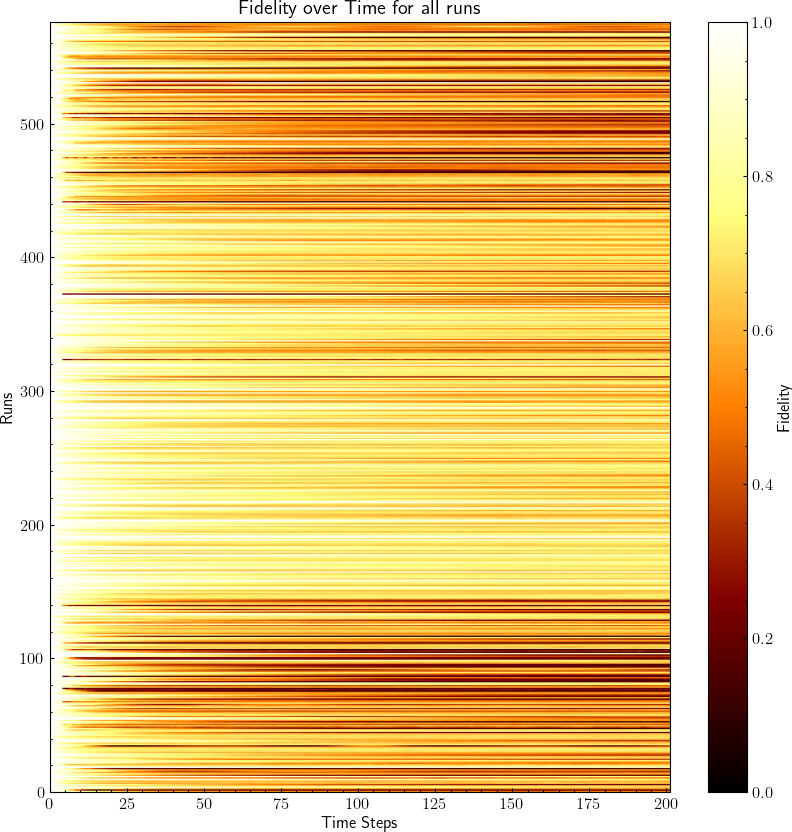

In [3]:
fig, ax, im = plot_runs(
    fidelities_mat,
    params_grouped,
    sort_by="s",
    show_labels=False,
    figsize=(10,10),
)
ax.set_title("Fidelity over Time for all runs")

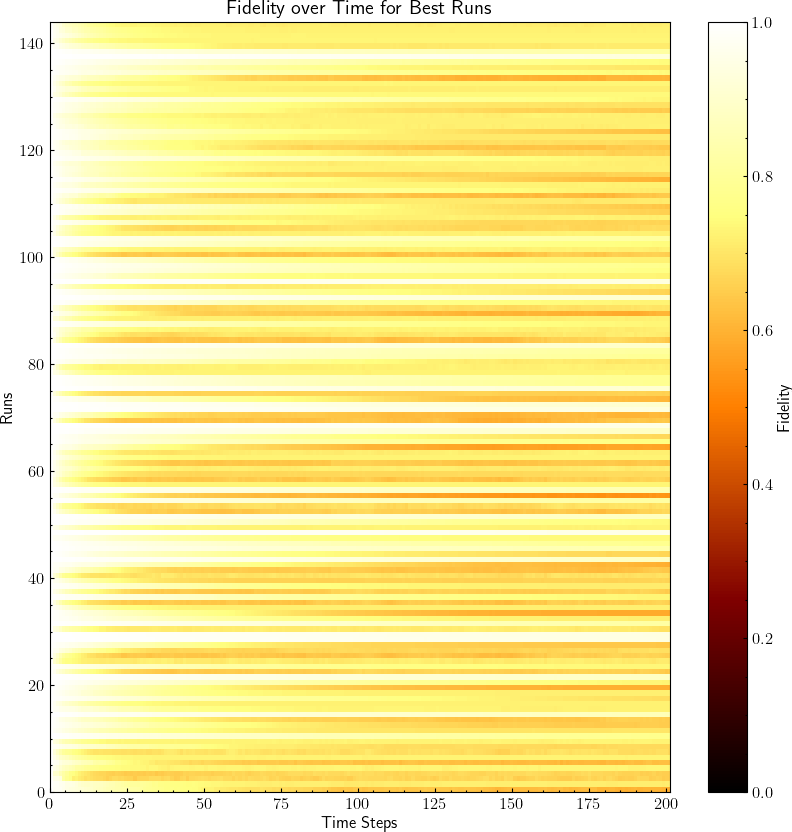

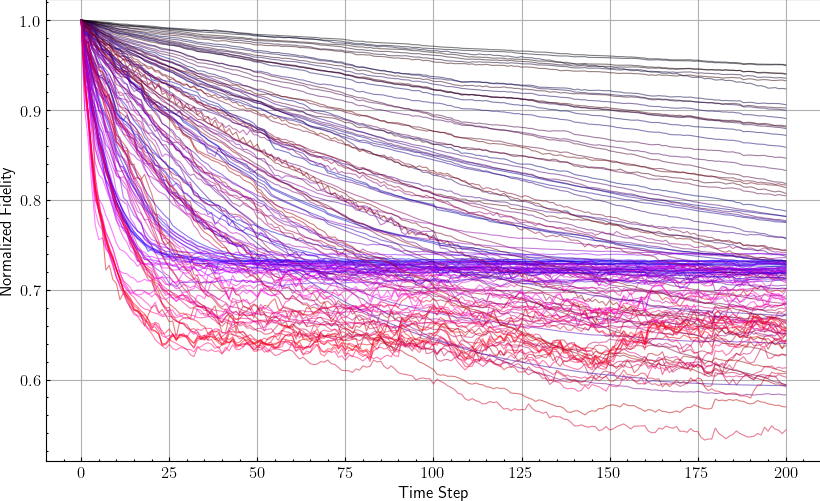

In [4]:
fig, ax, im = plot_runs(
    fidelities_best_mat,
    params_grouped_best,
    sort_by="s",
    show_labels=False,
    figsize=(10,10),
)
ax.set_title("Fidelity over Time for Best Runs")

idx = np.arange(fidelities_best_mat.shape[0]) #np.random.choice(fidelities_best_mat.shape[0], N, replace=False)
fig, ax = plot_runs_1D(
    fidelities_best_mat[idx],
    {param: [params_grouped_best[param][i] for i in idx] for param in params_grouped_best},
    figsize=(10,6),
)

Opening files...


100%|██████████| 145/145 [00:00<00:00, 4120.73it/s]

Done.


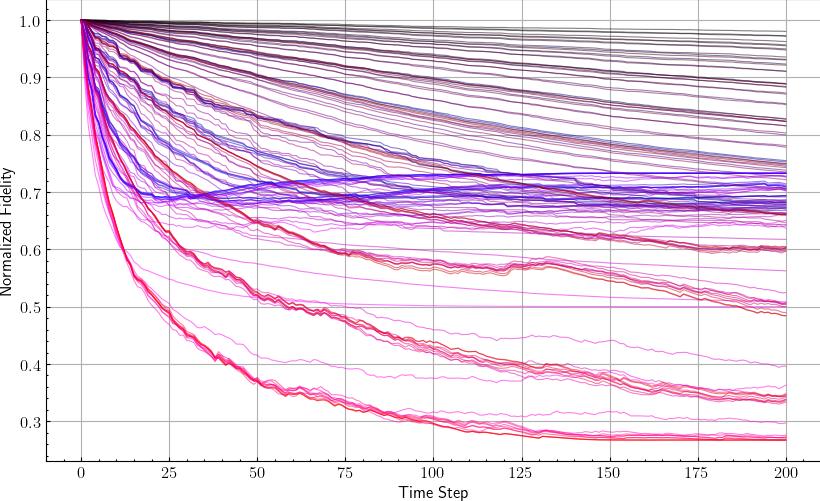

In [5]:
fidelities_mat_base, params_grouped_base, params_each_base = open_from_dir(dir_ + "/baseline")

idx = np.arange(fidelities_mat_stab.shape[0])
fig, ax = plot_runs_1D(
    fidelities_mat_stab[idx],
    {param: [params_grouped_stab[param][i] for i in idx] for param in params_grouped_stab},
    figsize=(10,6),
)

0.11252743599576216 2.4901523251722812
0.19997340240061148 1.5763569806544298
0.3986165092366334 2.3592334286259695


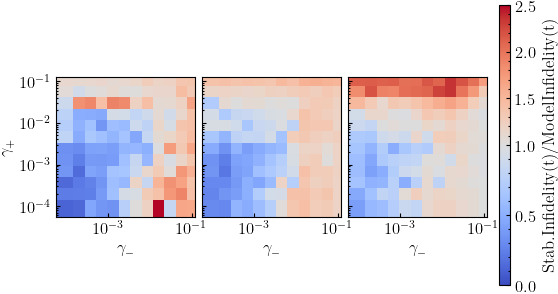

In [6]:
analyse_timesteps = [2,20,200]#[10, 50, 200]

norm = mcolors.TwoSlopeNorm(
    vmin=0.0,
    vcenter=1.0,
    vmax=2.5
)

def plot_single_timestep(i, t, ax, params_grouped):
    p1 = 1 - fidelities_best_mat[:, t] # Error probabilities at time t for model
    p2 = 1 - fidelities_mat_stab[:, t] # Error probabilities at time t for stabilizer code

    gamma_m_values, gamma_p_values, p1_grid = grid_grouped_params(p1, params_grouped, "gammam", "gammap")
    gamma_m_values2, gamma_p_values2, p2_grid = grid_grouped_params(p2, params_grouped, "gammam", "gammap")
    assert np.allclose(gamma_m_values, gamma_m_values2)
    assert np.allclose(gamma_p_values, gamma_p_values2)

    vals = p2_grid / p1_grid
    print(np.min(vals), np.max(vals))
    im = ax.pcolormesh(
        gamma_m_values,
        gamma_p_values,
        p2_grid / p1_grid,
        cmap='coolwarm',
        norm=norm,
    )
    ax.set_xlabel("$\\gamma_-$")
    if i == 0:
        ax.set_ylabel("$\\gamma_+$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_aspect('equal')

    return im

fig, axs = plt.subplots(1, len(analyse_timesteps), figsize=(6.1811 - 1.2/2.54, 4), sharey=True)
for i, t in enumerate(analyse_timesteps):
    im = plot_single_timestep(i, t, axs[i], params_grouped_best)

plt.subplots_adjust(wspace=0.05, hspace=0, right=0.88)

# colorbar on the right
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="$\\rm{Stab. Infidelity}(t)$/$\\rm{Model Infidelity}(t)$")
fig.savefig(f"{dir_}/comparison_stabilizer_vs_model.svg")

plt.show()